In [81]:
import os, sys, glob, shutil, re, pickle
import seaborn as sns

import mdtraj as md
import matplotlib.pyplot as plt
import matplotlib as mpl
import matplotlib.cm as cm
import numpy as np
import pandas as pd
import math
import pyemma

from IPython.display import Image, display
%matplotlib inline
nmer = 5
mpl.rcParams.update({'font.size': 16})

## Important function

In [82]:
class Data:
    def __init__(self, array_list):
        self.array_list = array_list

    def save(self, filename):
        with open(filename, 'wb') as f:
            pickle.dump(self.array_list, f)

    @classmethod
    def load(cls, filename):
        with open(filename, 'rb') as f:
            array_list = pickle.load(f)
        return cls(array_list)

In [ ]:
# Define the directory path
directory = "traj_data/"

remove_and_clean = False

# Check if the directory exists
if os.path.exists(directory):
    if remove_and_clean:
        # Remove all contents of the directory
        shutil.rmtree(directory)
        # Recreate the empty directory
        os.makedirs(directory)
        print(f"All contents in '{directory}' have been cleared.")
    else:
        print(f"Directory '{directory}' already exists. No action taken.")
else:
    # Create the directory if it does not exist
    os.makedirs(directory)
    print(f"Directory '{directory}' did not exist, so it has been created.")

Directory 'traj_data/' already exists. No action taken.


In [71]:
# Define the directory path
directory = "fig/"

remove_and_clean = True

# Check if the directory exists
if os.path.exists(directory):
    if remove_and_clean:
        # Remove all contents of the directory
        shutil.rmtree(directory)
        # Recreate the empty directory
        os.makedirs(directory)
        print(f"All contents in '{directory}' have been cleared.")
    else:
        print(f"Directory '{directory}' already exists. No action taken.")
else:
    # Create the directory if it does not exist
    os.makedirs(directory)
    print(f"Directory '{directory}' did not exist, so it has been created.")

All contents in 'fig/' have been cleared.


## Extract Distance Restraints

In [2]:
restraints_table = {
    'weak': 5,
    'medium': 3.5,
    'strong': 2.5
}

dist_res_file = '../../../utils/nspe_7_1_restraints.csv'
df_dist_res = pd.read_csv(dist_res_file)

for i, row in df_dist_res.iterrows():
    df_dist_res.at[i, df_dist_res.columns[2]] = restraints_table[row[2]]  # Correct mapping

# Make a look up table for intensity 
df_dist_res
dist_res = df_dist_res.values.tolist()
dist_res[:5]

/var/folders/d8/y2dvs1ln1gjcwccrkvtffr240000gn/T/ipykernel_31352/3498405480.py:11: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  df_dist_res.at[i, df_dist_res.columns[2]] = restraints_table[row[2]]  # Correct mapping


[[160, 165, 5], [160, 166, 5], [161, 165, 5], [161, 166, 5], [137, 165, 5]]

In [41]:
gmx_distance_indices = np.array(df_dist_res.iloc[:, :2].values.tolist())

distance_indices = gmx_distance_indices - 1 

# Ensure the omega_data directory exists
omega_path = 'traj_data/'

state_num = 16
HREX_dir = '../traj_remd'
run_num = 10 # How many run

HREX_list = [f"REMD_200ns_{i}" for i in range(1, run_num + 1)]
for state in range(state_num):
    dists_list = []
    for HREX in HREX_list:
        HREX_path = f"{HREX_dir}/{HREX}"  

        xtcfile = f"{HREX_path}/state_{state}/HREMD.part0001.xtc"
        grofile = f"../nspe_7_1.amb2gmx/nspe_7_1_GMX.gro"
        
        # Load the trajectory
        traj = md.load(xtcfile, top=grofile)
        
        # Compute distances 
        dists = md.compute_distances(traj, distance_indices) * 10.0 # convert nm to Å
        dists_list.append(dists)
        
    # Save distances
    concatenated_dists = np.vstack(dists_list)
    data_object = Data(concatenated_dists)
    save_path = f"{omega_path}dist_state{state}.pkl"
    data_object.save(save_path)
    print(f"Saved distances for state {state} to {save_path}")


Saved distances for state 0 to traj_data/dist_state0.pkl
Saved distances for state 1 to traj_data/dist_state1.pkl
Saved distances for state 2 to traj_data/dist_state2.pkl
Saved distances for state 3 to traj_data/dist_state3.pkl
Saved distances for state 4 to traj_data/dist_state4.pkl
Saved distances for state 5 to traj_data/dist_state5.pkl
Saved distances for state 6 to traj_data/dist_state6.pkl
Saved distances for state 7 to traj_data/dist_state7.pkl
Saved distances for state 8 to traj_data/dist_state8.pkl
Saved distances for state 9 to traj_data/dist_state9.pkl
Saved distances for state 10 to traj_data/dist_state10.pkl
Saved distances for state 11 to traj_data/dist_state11.pkl
Saved distances for state 12 to traj_data/dist_state12.pkl
Saved distances for state 13 to traj_data/dist_state13.pkl
Saved distances for state 14 to traj_data/dist_state14.pkl
Saved distances for state 15 to traj_data/dist_state15.pkl


## Reloaded Distance Restraints

In [4]:
nstates = 16

dist_all = []
for i in range(nstates):
    dist_path = f"traj_data/dist_state{i}.pkl"
    dist = Data.load(dist_path)
    dist = dist.array_list
    print(f'state {i}:, {np.array(dist).shape}')
    dist_all.append(dist)

dist_all = np.array(dist_all)
print('dist_all.shape', dist_all.shape)

state 0:, (200010, 76)
state 1:, (200010, 76)
state 2:, (200010, 76)
state 3:, (200010, 76)
state 4:, (200010, 76)
state 5:, (200010, 76)
state 6:, (200010, 76)
state 7:, (200010, 76)
state 8:, (200010, 76)
state 9:, (200010, 76)
state 10:, (200010, 76)
state 11:, (200010, 76)
state 12:, (200010, 76)
state 13:, (200010, 76)
state 14:, (200010, 76)
state 15:, (200010, 76)
dist_all.shape (16, 200010, 76)


### Distribution of all restraints 

In [5]:
## Featurize the structure 
grofile = f"../nspe_7_1.amb2gmx/nspe_7_1_GMX.gro"
feat = pyemma.coordinates.featurizer(grofile) 
feat.add_distances([67, 16])
feat.describe()

31-07-25 07:32:26 pyemma.coordinates.data.featurization.featurizer.MDFeaturizer[0] WARNING  The 1D arrays input for add_distances() have been sorted, and index duplicates have been eliminated.
Check the output of describe() to see the actual order of the features


['DIST: H02 1 H5 16 - R02 3 H10 67']

In [44]:
dist_res[:5]

[[160, 165, 5], [160, 166, 5], [161, 165, 5], [161, 166, 5], [137, 165, 5]]

In [45]:
atomtype_lookup = {
    ('H02', 'H12'): 'α11',
    ('H02', 'H13'): 'α11',
    ('H02', 'H3'): 'α2',
    ('H02', 'H4'): 'β3',
    ('H02', 'H5'): 'β3',
    ('H02', 'H6'): 'β3',
    ('R02', 'H10'): 'α11',
    ('R02', 'H11'): 'α11',
    ('R02', 'H1'): 'α2',
    ('R02', 'H2'): 'β3',
    ('R02', 'H3'): 'β3',
    ('R02', 'H4'): 'β3',
    ('NH2', 'HN1'): 'NH1',
    ('NH2', 'HN2'): 'NH1',
}


In [46]:
def translate_pyemma_label(label):
    # Remove 'DIST: ' prefix and whitespace
    label = label.replace('DIST: ', '').strip()
    
    # Split into two atoms
    part1, part2 = label.split(' - ')
    resname1, resid1, atomname1, atomid1 = part1.split()
    resname2, resid2, atomname2, atomid2 = part2.split()

    # Lookup group for each atom
    group1 = atomtype_lookup.get((resname1, atomname1), 'unknown')
    group2 = atomtype_lookup.get((resname2, atomname2), 'unknown')

    # Print (optional)
    print(f"Label: {label}")
    print(f"Residue 1: {resname1} {resid1}, Atom: {atomname1} ({atomid1}), Group: {group1}")
    print(f"Residue 2: {resname2} {resid2}, Atom: {atomname2} ({atomid2}), Group: {group2}")

    # Return formatted result
    return f"{resid1}{group1}-{resid2}{group2}"


Label: R02 7 H10 159 - NH2 8 HN1 164
Residue 1: R02 7, Atom: H10 (159), Group: α11
Residue 2: NH2 8, Atom: HN1 (164), Group: NH1
Label: R02 7 H10 159 - NH2 8 HN2 165
Residue 1: R02 7, Atom: H10 (159), Group: α11
Residue 2: NH2 8, Atom: HN2 (165), Group: NH1
Label: R02 7 H11 160 - NH2 8 HN1 164
Residue 1: R02 7, Atom: H11 (160), Group: α11
Residue 2: NH2 8, Atom: HN1 (164), Group: NH1
Label: R02 7 H11 160 - NH2 8 HN2 165
Residue 1: R02 7, Atom: H11 (160), Group: α11
Residue 2: NH2 8, Atom: HN2 (165), Group: NH1
Label: R02 6 H10 136 - NH2 8 HN1 164
Residue 1: R02 6, Atom: H10 (136), Group: α11
Residue 2: NH2 8, Atom: HN1 (164), Group: NH1
Label: R02 6 H10 136 - NH2 8 HN2 165
Residue 1: R02 6, Atom: H10 (136), Group: α11
Residue 2: NH2 8, Atom: HN2 (165), Group: NH1
Label: R02 6 H11 137 - NH2 8 HN1 164
Residue 1: R02 6, Atom: H11 (137), Group: α11
Residue 2: NH2 8, Atom: HN1 (164), Group: NH1
Label: R02 6 H11 137 - NH2 8 HN2 165
Residue 1: R02 6, Atom: H11 (137), Group: α11
Residue 2: NH2

/var/folders/d8/y2dvs1ln1gjcwccrkvtffr240000gn/T/ipykernel_47910/892030569.py:33: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = plt.boxplot(all_dists, vert=False, patch_artist=True, labels=labels)


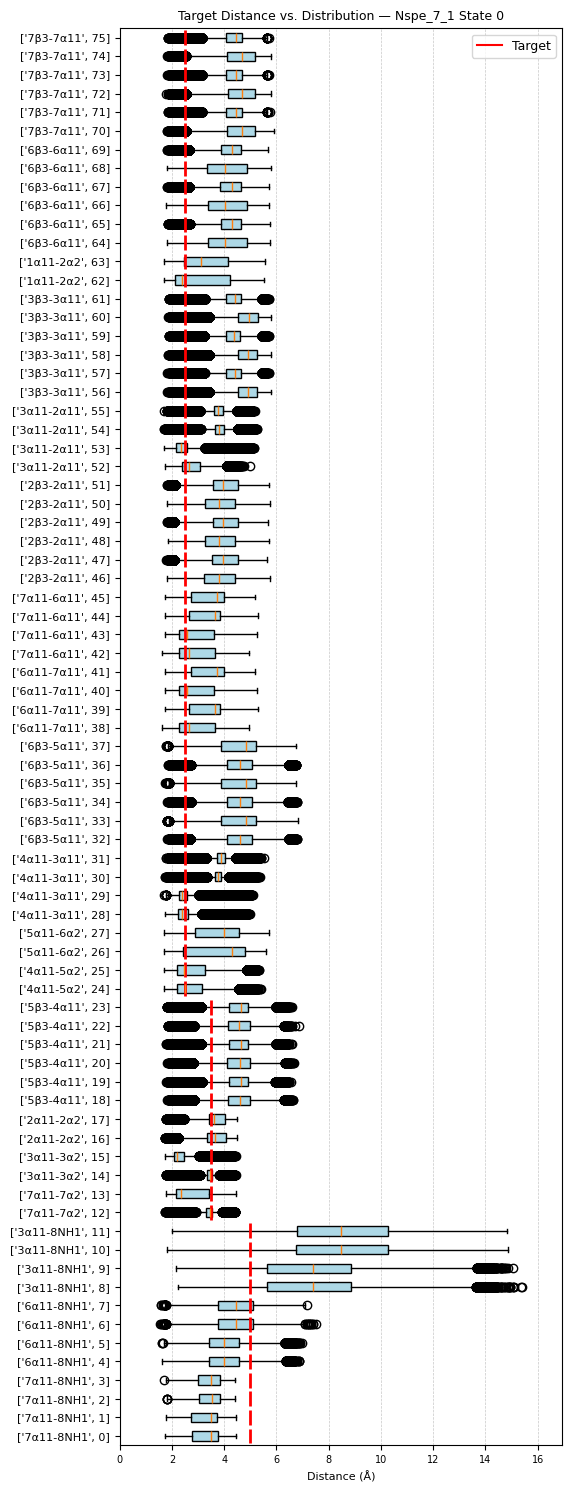

In [47]:
state_num = 16
human_interpretable_label = True

for state in range(1):  # Loop only over state 0
    targets = []
    labels = []
    all_dists = []

    for i in range(len(dist_res)):
        atom1, atom2, target = dist_res[i]
        atom1_pyemma = atom1 - 1
        atom2_pyemma = atom2 - 1
        dist = dist_all[state][:, i]  # shape: (n_frames,)

        all_dists.append(dist)
        targets.append(target)

        grofile = f"../nspe_7_1.amb2gmx/nspe_7_1_GMX.gro"
        feat = pyemma.coordinates.featurizer(grofile)
        feat.add_distances([[atom1_pyemma, atom2_pyemma]])
        label_raw = feat.describe()[0]

        if human_interpretable_label:
            label = [translate_pyemma_label(label=label_raw), i]
        else:
            label = [label_raw, i]
        labels.append(label)

    targets = np.array(targets)

    plt.figure(figsize=(6, max(6, len(labels) * 0.2)))
    # Plot horizontal box plots
    bp = plt.boxplot(all_dists, vert=False, patch_artist=True, labels=labels)

    # Optional styling: color boxes light blue
    for box in bp['boxes']:
        box.set(facecolor='lightblue')

    # Add target reference lines
    for yi, ti in enumerate(targets, start=1):  # boxplot y-ticks start at 1
        plt.vlines(ti, yi - 0.4, yi + 0.4, colors='red', linestyles='-', linewidth=2)
    plt.plot([], [], color='red', label='Target')  # legend entry

    plt.yticks(fontsize=8)
    plt.xlabel("Distance (Å)")
    plt.title(f"Target Distance vs. Distribution — Nspe_7_1 State {state}")
    plt.xlim(0, max([np.max(d) for d in all_dists] + list(targets)) * 1.1)
    plt.legend()
    plt.grid(axis='x', linestyle='--', linewidth=0.5, alpha=0.7)
    plt.tight_layout()
    plt.show()


### Distrances Over Time

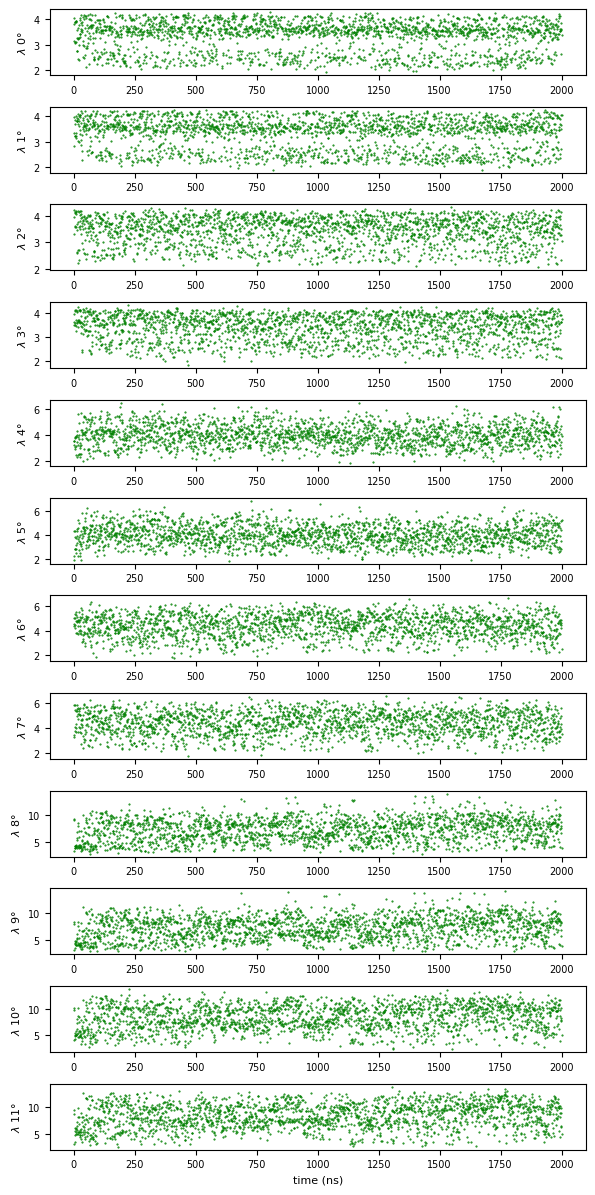

In [7]:
start = 0
nsnaps = dist_all.shape[1]
nreps = dist_all.shape[0]
steps_to_plot = 100
residues_to_plot = np.arange(0, 12).tolist()

#residues_to_plot = [0, 14, 70, 60] #5



num_residues = len(residues_to_plot)

ShowPlots = True

# Set default font sizes globally
plt.rc('font', size=8)         # controls default text sizes
plt.rc('axes', titlesize=9)    # fontsize of the axes title
plt.rc('axes', labelsize=8)    # fontsize of the x and y labels
plt.rc('xtick', labelsize=7)   # fontsize of the tick labels
plt.rc('ytick', labelsize=7)   # fontsize of the tick labels
plt.rc('legend', fontsize=9)   # legend fontsize

# Plot omega angles vs time for selected residues for each replica
for i in [0]:
    plt.figure(figsize=(6, 12))
    axes = []
    for panel, residue in enumerate(residues_to_plot, 1):
        if panel == 1:
            ax = plt.subplot(num_residues, 1, panel)  # First subplot
        else:
            ax = plt.subplot(num_residues, 1, panel, sharex=axes[0])  # Share x-axis with the first
        axes.append(ax)

        t = np.arange(start, nsnaps, steps_to_plot) * 0.010  # Time axis in ns
        ax.plot(t, dist_all[i, start:nsnaps:steps_to_plot, residue], '.', ms=1, color='green')
        ax.set_ylabel(f'$\\lambda$ {residue}°')
        if panel == num_residues:
            ax.set_xlabel('time (ns)')

    plt.tight_layout()
    #plt.show()

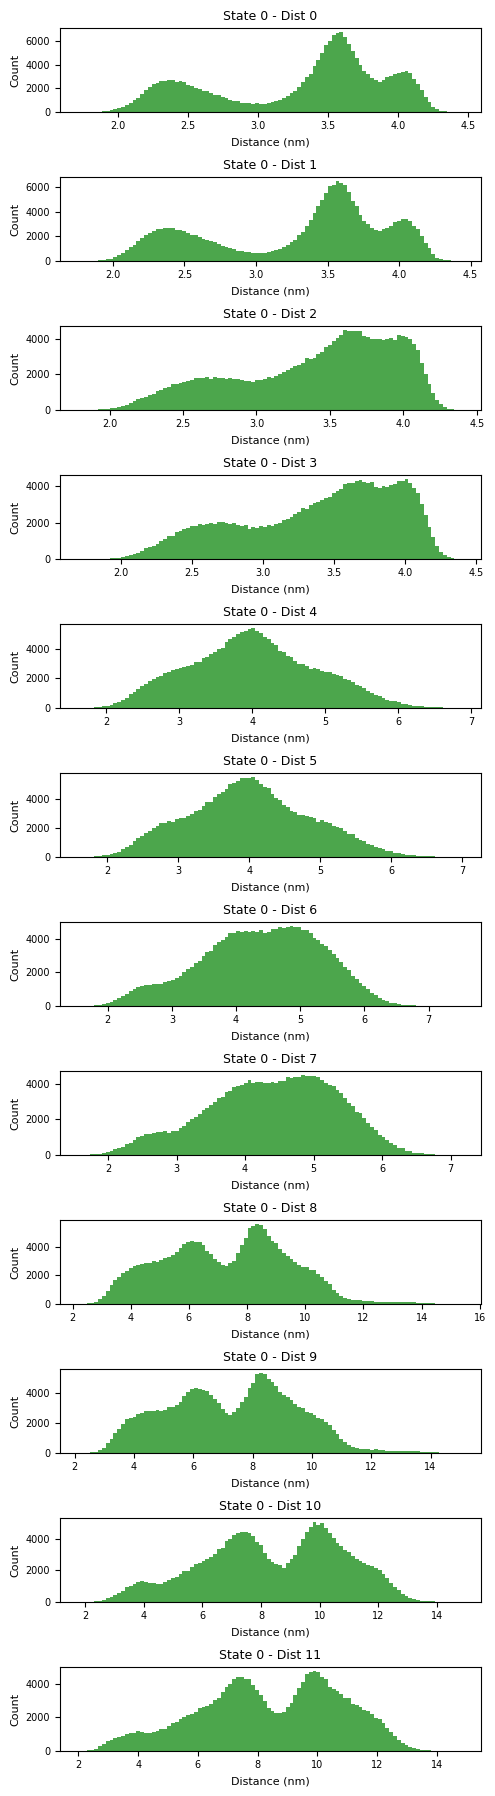

In [49]:
### Restrains Selected to show the effect, DON'T DELETE!!!!!!!!
#residues_to_plot = [63, 64] # 1 a11 - 2 a2
#residues_to_plot = [53, 54, 55, 56] # 2 a11 - 3 a11
#residues_to_plot = [29, 30, 31, 32] # 3 a11 - 4 a11
#residues_to_plot = [25, 26] # 4 a11 - 5 a2
#residues_to_plot = [27, 28] # 5 a11 - 6 a2
#residues_to_plot = [39, 40, 41, 42] # 6 a11 - 7 a11
#residues_to_plot = [9, 10, 11, 12] # 3 a11 - 8 nh1

residues_to_plot = np.arange(0, 12).tolist()

num_residues = len(residues_to_plot)
start = 0
nsnaps = dist_all.shape[1]
nreps = dist_all.shape[0]

for i in [0]:  # loop over selected replicas
    plt.figure(figsize=(5, 1.5 * num_residues))  # Adjust figure height dynamically
    for panel, residue in enumerate(residues_to_plot, 1):
        plt.subplot(num_residues, 1, panel)
        distances = dist_all[i, start:nsnaps, residue]
        plt.hist(distances, bins=100, color='green', alpha=0.7)
        plt.xlabel(f'Distance (nm)')
        plt.ylabel('Count')
        #plt.xlim(0.1, 0.7)
        plt.title(f'State {i} - Dist {residue}')
    plt.tight_layout()
    plt.show()


## Extract omega & phi restraints 

In [50]:
# hand input the omega indices:
# Define omega dihedral indices, gromcas start from 1, while np start from 0
gmx_dihedral_indices = np.array([
    [10, 11, 26, 44],
    [11, 26, 44, 47],
    [26, 44, 47, 49],
    [11, 26, 27, 33],

    [44, 47, 49, 67], 
    [47, 49, 67, 70],
    [49, 67, 70, 72],
    [47, 49, 50, 56],

    [67, 70, 72, 90],
    [70, 72, 90, 93],
    [72, 90, 93, 95],
    [70, 72, 73, 79],

    [90, 93, 95, 113],
    [93, 95, 113, 116],
    [95, 113, 116, 118],
    [93, 95, 96, 102],

    [113, 116, 118, 136],
    [116, 118, 136, 139],
    [118, 136, 139, 141],
    [116, 118, 119, 125],

    [136, 139, 141, 159],
    [139, 141, 159, 162],
    [141, 159, 162, 164],
    [139, 141, 142, 148]
])

omega_dihedral_indices = gmx_dihedral_indices - 1
print(omega_dihedral_indices)


HREX_list = [f"REMD_200ns_{i}" for i in range(1, run_num + 1)]
for state in range(state_num):
    omegas_list = []
    for HREX in HREX_list:
        HREX_path = f"{HREX_dir}/{HREX}"  

        xtcfile = f"{HREX_path}/state_{state}/HREMD.part0001.xtc"
        grofile = f"../nspe_7_1.amb2gmx/nspe_7_1_GMX.gro"
        
        # Load the trajectory
        traj = md.load(xtcfile, top=grofile)
        
        # Compute omega dihedrals
        omegas = md.compute_dihedrals(traj, omega_dihedral_indices) * (180.0 / math.pi)
        omegas_list.append(omegas)
    # Save omegas
    concatenated_omegas = np.vstack(omegas_list)
    data_object = Data(concatenated_omegas)
    save_path = f"{omega_path}omegas_state{state}.pkl"
    data_object.save(save_path)
    print(f"Saved omegas for state {state} to {save_path}")

[[  9  10  25  43]
 [ 10  25  43  46]
 [ 25  43  46  48]
 [ 10  25  26  32]
 [ 43  46  48  66]
 [ 46  48  66  69]
 [ 48  66  69  71]
 [ 46  48  49  55]
 [ 66  69  71  89]
 [ 69  71  89  92]
 [ 71  89  92  94]
 [ 69  71  72  78]
 [ 89  92  94 112]
 [ 92  94 112 115]
 [ 94 112 115 117]
 [ 92  94  95 101]
 [112 115 117 135]
 [115 117 135 138]
 [117 135 138 140]
 [115 117 118 124]
 [135 138 140 158]
 [138 140 158 161]
 [140 158 161 163]
 [138 140 141 147]]
Saved omegas for state 0 to traj_data/omegas_state0.pkl
Saved omegas for state 1 to traj_data/omegas_state1.pkl
Saved omegas for state 2 to traj_data/omegas_state2.pkl
Saved omegas for state 3 to traj_data/omegas_state3.pkl
Saved omegas for state 4 to traj_data/omegas_state4.pkl
Saved omegas for state 5 to traj_data/omegas_state5.pkl
Saved omegas for state 6 to traj_data/omegas_state6.pkl
Saved omegas for state 7 to traj_data/omegas_state7.pkl
Saved omegas for state 8 to traj_data/omegas_state8.pkl
Saved omegas for state 9 to traj_data/o

## Reloaded Omegas 

In [83]:
nstates = 16

omega_all = []
for i in range(nstates):
    omega_path = f"traj_data/omegas_state{i}.pkl"
    omegas = Data.load(omega_path)
    omegas = omegas.array_list
    print(f'state {i}:, {np.array(omegas).shape}')
    omega_all.append(omegas)

omega_all = np.array(omega_all)
omega_all.shape

state 0:, (200010, 24)
state 1:, (200010, 24)
state 2:, (200010, 24)
state 3:, (200010, 24)
state 4:, (200010, 24)
state 5:, (200010, 24)
state 6:, (200010, 24)
state 7:, (200010, 24)
state 8:, (200010, 24)
state 9:, (200010, 24)
state 10:, (200010, 24)
state 11:, (200010, 24)
state 12:, (200010, 24)
state 13:, (200010, 24)
state 14:, (200010, 24)
state 15:, (200010, 24)


(16, 200010, 24)

In [84]:
residues_to_plot = np.arange(0, 24, 4).tolist()  # Modify if needed

omega_indices = [r for r in residues_to_plot]
phi_indices   = [r + 1 for r in residues_to_plot]
psi_indices   = [r + 2 for r in residues_to_plot]
chi1_indices  = [r + 3 for r in residues_to_plot]

for angle_indices in [omega_indices, psi_indices, chi1_indices]:
    omega_all[:, :, angle_indices] = (omega_all[:, :, angle_indices] + 90.0) % 360.0 - 90.0

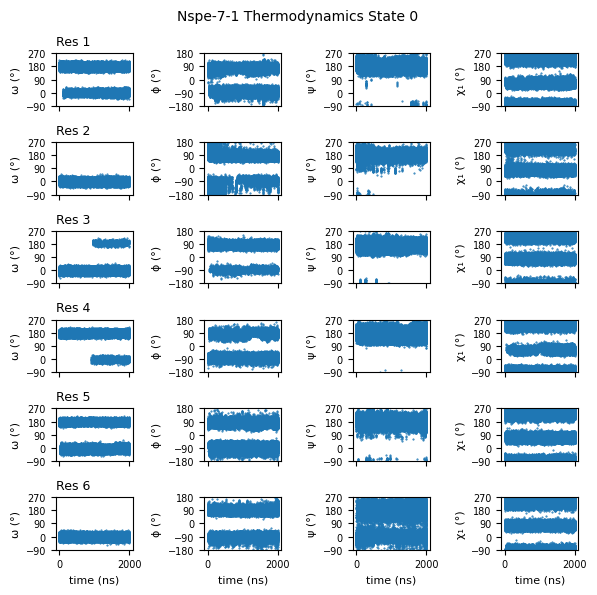

In [85]:
start = 0
nsnaps = omega_all.shape[1]
t = np.arange(start, nsnaps) * 0.010  # time in ns
num_residues = len(residues_to_plot)
replicas_to_plot = [0]  # Which replicas to visualize

# Set global font sizes
plt.rc('font', size=8)
plt.rc('axes', titlesize=9)
plt.rc('axes', labelsize=8)
plt.rc('xtick', labelsize=7)
plt.rc('ytick', labelsize=7)
plt.rc('legend', fontsize=9)

for i in replicas_to_plot:
    fig, axes = plt.subplots(nrows=num_residues, ncols=4, figsize=(6, 1 * num_residues), sharex=True)

    for row, residue in enumerate(residues_to_plot):
        angles = {
            'ω':  omega_all[i, start:nsnaps, omega_indices[row]],
            'ϕ':  omega_all[i, start:nsnaps, phi_indices[row]],
            'ψ':  omega_all[i, start:nsnaps, psi_indices[row]],
            'χ₁': omega_all[i, start:nsnaps, chi1_indices[row]],
        }

        for col, (label, data) in enumerate(angles.items()):
            ax = axes[row, col] if num_residues > 1 else axes[col]
            ax.plot(t, data, '.', ms=1)
            ax.set_ylabel(f'{label} (°)')

            # Set y-axis limits
            if label in ['ω', 'χ₁', 'ψ']:
                ax.set_ylim(-90, 270)
                ax.set_yticks(np.arange(-90, 271, 90))
            # Uncomment below to use traditional [-180, 180] for φ 
            if label in ['ϕ']:
                ax.set_ylim(-180, 180)
                ax.set_yticks(np.arange(-180, 181, 90))

            if row == num_residues - 1:
                ax.set_xlabel('time (ns)')
            if col == 0:
                ax.set_title(f'Res {residue // 4 + 1}', loc='left')

    fig.suptitle(f'Nspe-7-1 Thermodynamics State {i}', fontsize=10)
    fig.tight_layout(rect=[0, 0, 1, 1])
    fig.savefig("fig/backbone_angle_over_time_nspe71.png", format="png", dpi=300, bbox_inches="tight")
    plt.show()

### Dihedrals Pairs

In [11]:
omega_all.shape

(16, 200010, 24)

In [67]:
import matplotlib.gridspec as gridspec

def plot_dihedral_quadruplets(
    omega_all,
    residues_to_plot,
    states=range(16),
    use_latex=True,
    angles_to_plot=None
):
    """
    Plot selected dihedral angle pairs for each residue in each state.

    Parameters:
    -----------
    omega_all : np.ndarray
        Shape (n_states, n_frames, n_dihedrals)
    residues_to_plot : list of int
        Starting indices of each residue block (omega, phi, psi, chi1)
    states : list
        Indices of states to plot
    use_latex : bool
        Use LaTeX formatting for labels
    angles_to_plot : list of str
        Angle pairs to plot. Options:
            'omega_phi', 'omega_psi', 'phi_psi',
            'omega_chi1', 'phi_chi1', 'psi_chi1'
    """
    if angles_to_plot is None:
        angles_to_plot = ["omega_phi", "omega_psi", "phi_psi", "omega_chi1", "phi_chi1", "psi_chi1"]

    scatter_kws = dict(s=2, color='black', alpha=0.3)

    # Axis labels
    if use_latex:
        labels = {
            'phi': r'$\phi$',
            'psi': r'$\psi$',
            'omega': r'$\omega$',
            'chi1': r'$\chi_1$'
        }
    else:
        labels = {
            'phi': 'Phi',
            'psi': 'Psi',
            'omega': 'Omega',
            'chi1': 'Chi1'
        }

    def format_ax(ax, xlabel, ylabel):
        """Set axis limits and ticks based on dihedral type."""
        if labels['phi'] in xlabel:
            ax.set_xlim(-180, 180)
            ax.set_xticks(np.arange(-180, 181, 180))
        else:
            ax.set_xlim(-90, 270)
            ax.set_xticks(np.arange(-90, 271, 180))

        if labels['phi'] in ylabel:
            ax.set_ylim(-180, 180)
            ax.set_yticks(np.arange(-180, 181, 180))
        else:
            ax.set_ylim(-90, 270)
            ax.set_yticks(np.arange(-90, 271, 180))

        ax.set_xlabel(xlabel)
        ax.set_ylabel(ylabel)

    # Mapping from angle pair name to (x, y) keys and title suffix
    angle_plot_map = {
        'omega_phi':   ('phi',   'omega'),
        'omega_psi':   ('psi',   'omega'),
        'phi_psi':     ('psi',   'phi'),
        'omega_chi1':  ('chi1',  'omega'),
        'phi_chi1':    ('chi1',  'phi'),
        'psi_chi1':    ('chi1',  'psi'),
    }

    for state_idx in states:
        num_residues = len(residues_to_plot)
        num_pairs = len(angles_to_plot)
        nrows = num_residues
        ncols = num_pairs

        fig, axes = plt.subplots(
                        nrows, ncols,
                        figsize=(1.1 * ncols, 0.5 * nrows + 0.1),
                        gridspec_kw={'wspace': 0.7}  # adjust spacing as needed
                    )
                            
        axes = np.atleast_2d(axes)

        fig.suptitle(f'Nspe_7_1 — State {state_idx}', fontsize=10)

        for row_idx, residue in enumerate(residues_to_plot):
            omega = omega_all[state_idx, :, residue]
            phi   = omega_all[state_idx, :, residue + 1]
            psi   = omega_all[state_idx, :, residue + 2]
            chi1  = omega_all[state_idx, :, residue + 3]

            angle_data = {
                'omega': omega,
                'phi':   phi,
                'psi':   psi,
                'chi1':  chi1,
            }

            for col_idx, angle_pair in enumerate(angles_to_plot):
                x_key, y_key = angle_plot_map[angle_pair]
                x = angle_data[x_key]
                y = angle_data[y_key]
                ax = axes[row_idx, col_idx]
                ax.scatter(x, y, **scatter_kws)
                format_ax(ax, labels[x_key], labels[y_key])

                if row_idx == 0:
                    ax.set_title(f'{labels[y_key]} vs {labels[x_key]}')
                if col_idx == 0:
                    ax.set_ylabel(f'Res {residue//4}\n{labels[y_key]}')

        plt.tight_layout(rect=[0.04, 0.05, 0.99, 0.99])
        plt.show()


/var/folders/d8/y2dvs1ln1gjcwccrkvtffr240000gn/T/ipykernel_33239/3130005504.py:120: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0.04, 0.05, 0.99, 0.99])


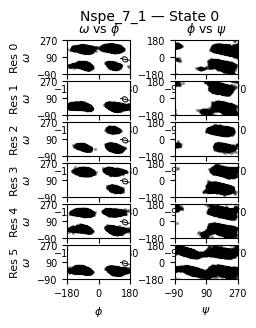

In [68]:
# Available options for angles_to_plot:

# "phi_psi"      # Plot ψ vs φ
# "omega_phi"    # Plot φ vs ω
# "omega_psi"    # Plot ψ vs ω
# "omega_chi1"   # Plot χ₁ vs ω
# "phi_chi1"     # Plot χ₁ vs φ
# "psi_chi1"     # Plot χ₁ vs ψ


# Full set (default)
plot_dihedral_quadruplets(omega_all, residues_to_plot, states=[0], angles_to_plot=["omega_phi", "phi_psi"])

In [14]:
data_path = 'traj_data/omegas_state0.pkl'

# Load the data
loaded_data = Data.load(data_path)
# Access the list of arrays
array_list = loaded_data.array_list

# Print a slice of the data
print(array_list[200:205])
# Print the shape
print(np.array(array_list).shape)

[[-1.74729416e+02  6.86247406e+01 -1.70723373e+02 -6.49804840e+01
  -1.33564639e+00 -9.81301956e+01 -1.48842972e+02  7.82315826e+01
  -2.01186991e+00  9.49094315e+01  1.57761261e+02  7.81507797e+01
  -1.79108887e+02 -1.49296936e+02 -1.65646820e+02 -1.44488174e+02
  -1.75560059e+02  7.62239075e+01 -1.71028030e+02 -1.47703781e+02
   1.51828015e+00  9.65835953e+01 -4.26011810e+01 -1.61847046e+02]
 [ 1.74615158e+02  7.90706940e+01 -1.33993500e+02 -5.27022781e+01
  -1.70425816e+01 -7.25598221e+01 -1.69022491e+02 -7.95724182e+01
   2.50399661e+00  8.80375519e+01  1.61374771e+02 -7.65744095e+01
   1.67673599e+02 -8.53006744e+01 -1.71171753e+02 -7.59704742e+01
   1.76543091e+02  7.00525131e+01 -1.44689499e+02 -1.44637238e+02
  -3.85386419e+00  9.27451553e+01 -1.91004887e+01  7.33594742e+01]
 [-1.71875305e+02  5.08053398e+01 -1.16523262e+02 -8.27682343e+01
   1.80799615e+00 -7.89931107e+01 -1.69773743e+02 -8.59367523e+01
  -4.68767595e+00  9.00091248e+01  1.57633347e+02 -5.99915123e+01
   1.757

In [58]:
for i in range(nstates):
    omega_path = f"traj_data/omegas_state{i}.pkl"
    omegas = Data.load(omega_path)
    omegas = omegas.array_list
    print(f'state {i}:, {np.array(omegas).shape}')

state 0:, (200010, 24)
state 1:, (200010, 24)
state 2:, (200010, 24)
state 3:, (200010, 24)
state 4:, (200010, 24)
state 5:, (200010, 24)
state 6:, (200010, 24)
state 7:, (200010, 24)
state 8:, (200010, 24)
state 9:, (200010, 24)
state 10:, (200010, 24)
state 11:, (200010, 24)
state 12:, (200010, 24)
state 13:, (200010, 24)
state 14:, (200010, 24)
state 15:, (200010, 24)


## Extract the exchanged stated from log file

In [59]:
current_state = np.arange(0, state_num, 1).tolist()
current_state


[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15]

In [60]:
pattern = 'Repl ex'
output_file = 'replica_indices.dat'

states = []
states.append( current_state.copy() ) # Make a copy of initial_state

# DEbug:  Let's see if xtc is written BEFORE swap 
states.append( current_state.copy() ) # Make a copy of initial_state

VERBOSE = False

for HREX in HREX_list:
    HREX_path = f"{HREX_dir}/{HREX}"
    try:
        logfile = os.path.join(HREX_path , 'state_0/HREMD.part0001.log')
        with open(logfile, 'r') as file:
            lines = file.readlines()

            for line in lines:
                if pattern in line:
                    parts = line.strip().split()
                    if VERBOSE:
                        print(f'parts: {parts}')
                    for i in range(2, len(parts)):
                        if 'x' in parts[i]:
                            index1 = int(parts[i-1])
                            index2 = int(parts[i+1])
                            if VERBOSE:
                                print(current_state)
                                print('index1, index2', index1, index2)
                            # Swap the positions in the current state
                            tmp1, tmp2 = current_state[index1], current_state[index2]
                            if VERBOSE:
                                print('tmp1, tmp2', tmp1, tmp2)
                            current_state[index2] = tmp1
                            current_state[index1] = tmp2
                            if VERBOSE:
                                print(current_state)
                    states.append(current_state.copy())  # Append a copy of the last state
        
        # Append twice for the last frame
        states.append(current_state.copy())
        states.append(current_state.copy())

    except FileNotFoundError:
        print(f"The file {logfile} does not exist.")
    except Exception as e:
        print(f"An error occurred: {e}")

# Remove the final two lines from states
if len(states) > 2:
    states = states[:-2]


# Write states to output_file
with open(output_file, 'w') as outfile:
    for state in states:
        outfile.write(' '.join(map(str, state)) + '\n')

print(f"Output saved to {output_file}")


Output saved to replica_indices.dat


In [61]:
states = np.array(states)
states.shape

(2000010, 16)

In [62]:
states = np.array(states)

state_all = []

block_size = 100001
stride = 5
for i, label in enumerate(HREX_list):
    print(i, label)

    start = block_size * i
    end = block_size * (i + 1)
    state = states[start:end:stride]
    state_all.append(state)
    print(f"state_{label}.shape = {state.shape}")

# Stack and save
state_new = np.vstack(state_all)
print(f"state_new.shape = {state_new.shape}")
np.savetxt('state_new.dat', state_new.astype(int), fmt='%d')
print("Saved data at state_new.dat")

0 REMD_200ns_1
state_REMD_200ns_1.shape = (20001, 16)
1 REMD_200ns_2
state_REMD_200ns_2.shape = (20001, 16)
2 REMD_200ns_3
state_REMD_200ns_3.shape = (20001, 16)
3 REMD_200ns_4
state_REMD_200ns_4.shape = (20001, 16)
4 REMD_200ns_5
state_REMD_200ns_5.shape = (20001, 16)
5 REMD_200ns_6
state_REMD_200ns_6.shape = (20001, 16)
6 REMD_200ns_7
state_REMD_200ns_7.shape = (20001, 16)
7 REMD_200ns_8
state_REMD_200ns_8.shape = (20001, 16)
8 REMD_200ns_9
state_REMD_200ns_9.shape = (20001, 16)
9 REMD_200ns_10
state_REMD_200ns_10.shape = (20001, 16)
state_new.shape = (200010, 16)
Saved data at state_new.dat


## Extract each replica 

In [21]:
nres = 24
state_num = 16
all_omegas = [] # Load in the omega values for all replicas

for state in range(state_num):  # Adjust the range to include all replicas
    omega_path = f"traj_data/omegas_state{state}.pkl"
    omegas = Data.load(omega_path)
    omegas = omegas.array_list
    all_omegas.append(np.array(omegas))
all_omegas = np.array(all_omegas)  # (nreps, nsnaps, nresidues)
print('all_omegas.shape', all_omegas.shape)
#print(all_omegas[:5])

# Arrange each snapshot by replica (not temp)
replica_indices = np.loadtxt('state_new.dat')
print("replica_indices.shape", replica_indices.shape)
#print(replica_indices)

start = 0
nsnaps = replica_indices.shape[0]
nreps = state_num

all_omegas_by_replica = np.zeros(all_omegas.shape)
all_omegas_by_replica_and_state = np.zeros((nreps, nsnaps, nres + 1)) # Make a instance recorded teh state and replica 
replica_indices_sorted = np.zeros_like(replica_indices)

for i in range(nsnaps):
    Ind = np.argsort(replica_indices[i, :])
    all_omegas_by_replica[:, i, :] = all_omegas[Ind, i, :]
    replica_indices_sorted[i, :] = Ind

# Save the data for each state once
for rep in range(nreps):
    save_path = f"traj_data/omegas_rep{rep}.pkl"
    rep_object = Data(all_omegas_by_replica[rep, :, :])
    rep_object.save(save_path)
    print(f"Saved omegas for replica {rep} to {save_path}")
    #print(np.load(f'omega_data/omegas_rep{rep}.npy')[:5])

# Create a replica + state_indices 
for i in range(nsnaps):
    Ind = np.argsort(replica_indices[i, :]) # find the index of replica
    all_omegas_by_replica_and_state[:, i, :-1] = all_omegas[Ind, i, :]
    all_omegas_by_replica_and_state[:, i, -1] = Ind  # State is found by indexing
    #print(all_omegas_by_replica_and_state)

print('replica_indices_sorted.shape', replica_indices_sorted.shape)
print('replica_indices_sorted[:10, 0]', replica_indices_sorted[:10, 0])

all_omegas.shape (16, 200010, 24)
replica_indices.shape (200010, 16)
Saved omegas for replica 0 to traj_data/omegas_rep0.pkl
Saved omegas for replica 1 to traj_data/omegas_rep1.pkl
Saved omegas for replica 2 to traj_data/omegas_rep2.pkl
Saved omegas for replica 3 to traj_data/omegas_rep3.pkl
Saved omegas for replica 4 to traj_data/omegas_rep4.pkl
Saved omegas for replica 5 to traj_data/omegas_rep5.pkl
Saved omegas for replica 6 to traj_data/omegas_rep6.pkl
Saved omegas for replica 7 to traj_data/omegas_rep7.pkl
Saved omegas for replica 8 to traj_data/omegas_rep8.pkl
Saved omegas for replica 9 to traj_data/omegas_rep9.pkl
Saved omegas for replica 10 to traj_data/omegas_rep10.pkl
Saved omegas for replica 11 to traj_data/omegas_rep11.pkl
Saved omegas for replica 12 to traj_data/omegas_rep12.pkl
Saved omegas for replica 13 to traj_data/omegas_rep13.pkl
Saved omegas for replica 14 to traj_data/omegas_rep14.pkl
Saved omegas for replica 15 to traj_data/omegas_rep15.pkl
replica_indices_sorted.

In [64]:
nstates = 16

all_dist = []
for i in range(nstates):
    dist_path = f"traj_data/dist_state{i}.pkl"
    dist = Data.load(dist_path)
    dist = dist.array_list
    print(f'state {i}:, {np.array(dist).shape}')
    all_dist.append(dist)

all_dist = np.array(all_dist)
print('all_dist.shape', all_dist.shape)

# Arrange each snapshot by replica (not temp)
replica_indices = np.loadtxt('state_new.dat')
print("replica_indices.shape", replica_indices.shape)
#print(replica_indices)

start = 0
nsnaps = replica_indices.shape[0]
nreps = state_num
nres = all_dist.shape[-1] # number of distance features

all_dist_by_replica = np.zeros(all_dist.shape)
all_dist_by_replica_and_state = np.zeros((nreps, nsnaps, nres + 1)) # Make a instance recorded teh state and replica 
replica_indices_sorted = np.zeros_like(replica_indices)

for i in range(nsnaps):
    Ind = np.argsort(replica_indices[i, :])
    all_dist_by_replica[:, i, :] = all_dist[Ind, i, :]
    replica_indices_sorted[i, :] = Ind

# Save the data for each state once
for rep in range(nreps):
    save_path = f"traj_data/dist_rep{rep}.pkl"
    rep_object = Data(all_dist_by_replica[rep, :, :])
    rep_object.save(save_path)
    print(f"Saved omegas for replica {rep} to {save_path}")

# Create a replica + state_indices 
for i in range(nsnaps):
    Ind = np.argsort(replica_indices[i, :]) # find the index of replica
    all_dist_by_replica_and_state[:, i, :-1] = all_dist[Ind, i, :]
    all_dist_by_replica_and_state[:, i, -1] = Ind  # State is found by indexing

print('replica_indices_sorted.shape', replica_indices_sorted.shape)
print('replica_indices_sorted[:10, 0]', replica_indices_sorted[:10, 0])

state 0:, (200010, 76)
state 1:, (200010, 76)
state 2:, (200010, 76)
state 3:, (200010, 76)
state 4:, (200010, 76)
state 5:, (200010, 76)
state 6:, (200010, 76)
state 7:, (200010, 76)
state 8:, (200010, 76)
state 9:, (200010, 76)
state 10:, (200010, 76)
state 11:, (200010, 76)
state 12:, (200010, 76)
state 13:, (200010, 76)
state 14:, (200010, 76)
state 15:, (200010, 76)
all_dist.shape (16, 200010, 76)
replica_indices.shape (200010, 16)
Saved omegas for replica 0 to traj_data/dist_rep0.pkl
Saved omegas for replica 1 to traj_data/dist_rep1.pkl
Saved omegas for replica 2 to traj_data/dist_rep2.pkl
Saved omegas for replica 3 to traj_data/dist_rep3.pkl
Saved omegas for replica 4 to traj_data/dist_rep4.pkl
Saved omegas for replica 5 to traj_data/dist_rep5.pkl
Saved omegas for replica 6 to traj_data/dist_rep6.pkl
Saved omegas for replica 7 to traj_data/dist_rep7.pkl
Saved omegas for replica 8 to traj_data/dist_rep8.pkl
Saved omegas for replica 9 to traj_data/dist_rep9.pkl
Saved omegas for re

## Replica Move through states

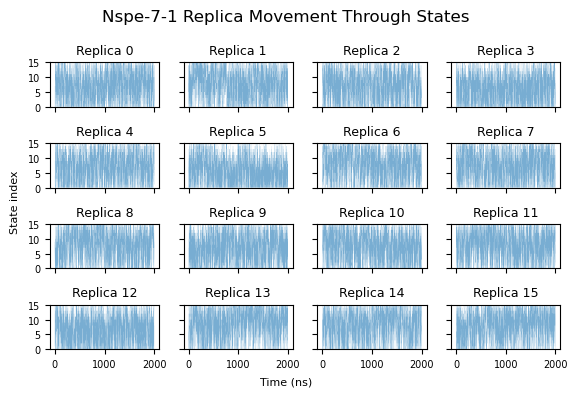

In [79]:
os.makedirs("fig", exist_ok=True)

step = 1
dt_in_ns = 0.01
nrows, ncols = 4, 4
fig, axes = plt.subplots(nrows, ncols, figsize=(6, 4), sharex=True, sharey=True)

for replica_id in range(replica_indices_sorted.shape[1]):
    ax = axes[replica_id // ncols, replica_id % ncols]

    x = np.arange(0, replica_indices_sorted.shape[0], step) * dt_in_ns
    y = replica_indices_sorted[:, replica_id][::step]

    ax.plot(x, y, linewidth=0.05, alpha=0.6)
    ax.set_title(f"Replica {replica_id}")
    ax.set_ylim(0, 15)
    ax.set_yticks([0, 5, 10, 15])

fig.suptitle("Nspe-7-1 Replica Movement Through States", fontsize=12)
fig.text(0.5, 0.04, 'Time (ns)', ha='center')
fig.text(0.04, 0.5, 'State index', va='center', rotation='vertical')
plt.tight_layout(rect=[0.05, 0.05, 0.99, 0.99])
fig.savefig("fig/replica_states_nspe71.png", format="png", dpi=300, bbox_inches="tight")
plt.show()

In [66]:
all_omegas_by_replica.shape

(16, 200010, 24)